In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
for root, dirs, files in os.walk("/kaggle/input"):
    print(root)
    print(files[:5])

/kaggle/input
[]
/kaggle/input/datasets
[]
/kaggle/input/datasets/vencerlanz09
[]
/kaggle/input/datasets/vencerlanz09/taco-dataset-yolo-format
['README.dataset.txt', 'README.roboflow.txt', 'data.yaml']
/kaggle/input/datasets/vencerlanz09/taco-dataset-yolo-format/valid
[]
/kaggle/input/datasets/vencerlanz09/taco-dataset-yolo-format/valid/labels
['000052_JPG_jpg.rf.37ee95937c69e8f097641e5487da719b.txt', '000095_jpg.rf.f04834eda4bb7582b4f7a8380b8676c9.txt', '000030_jpg.rf.8d4da2a81c714e7133277757eb4f8150.txt', '000111_JPG_jpg.rf.909d368cb4fb2db543eadafe9ed2b80c.txt', '000013_jpg.rf.c9273913862771c07071cc2920d1c886.txt']
/kaggle/input/datasets/vencerlanz09/taco-dataset-yolo-format/valid/images
['000118_JPG_jpg.rf.8809353b23c863ed7d52b139c3bdd2cf.jpg', '000021_JPG_jpg.rf.cc8a9b654b0fb3a89170fa88a91e938a.jpg', '000000_JPG_jpg.rf.7502211fb8242d7964e1ca87a3d02872.jpg', '000101_JPG_jpg.rf.93b2fb844cf5e3831c276c182b294421.jpg', '000003_JPG_jpg.rf.2e079b5980da7bb23d023b04fd723560.jpg']
/kaggle/in

In [3]:
BASE = "/kaggle/input/datasets/vencerlanz09/taco-dataset-yolo-format"

TRAIN_IMG = f"{BASE}/train/images"
TRAIN_LABEL = f"{BASE}/train/labels"

VALID_IMG = f"{BASE}/valid/images"
VALID_LABEL = f"{BASE}/valid/labels"

TEST_IMG = f"{BASE}/test/images"
TEST_LABEL = f"{BASE}/test/labels"

In [4]:
import yaml

with open(f"{BASE}/data.yaml", "r") as f:
    data = yaml.safe_load(f)

data

{'train': '../train/images',
 'val': '../valid/images',
 'test': '../test/images',
 'nc': 18,
 'names': ['Aluminium foil',
  'Bottle cap',
  'Bottle',
  'Broken glass',
  'Can',
  'Carton',
  'Cigarette',
  'Cup',
  'Lid',
  'Other litter',
  'Other plastic',
  'Paper',
  'Plastic bag - wrapper',
  'Plastic container',
  'Pop tab',
  'Straw',
  'Styrofoam piece',
  'Unlabeled litter'],
 'roboflow': {'workspace': 'divya-lzcld',
  'project': 'taco-mqclx',
  'version': 3,
  'license': 'CC BY 4.0',
  'url': 'https://universe.roboflow.com/divya-lzcld/taco-mqclx/dataset/3'}}

In [5]:
print("Number of classes:", data["nc"])
print("Classes:")
for i, name in enumerate(data["names"]):
    print(i, "->", name)

Number of classes: 18
Classes:
0 -> Aluminium foil
1 -> Bottle cap
2 -> Bottle
3 -> Broken glass
4 -> Can
5 -> Carton
6 -> Cigarette
7 -> Cup
8 -> Lid
9 -> Other litter
10 -> Other plastic
11 -> Paper
12 -> Plastic bag - wrapper
13 -> Plastic container
14 -> Pop tab
15 -> Straw
16 -> Styrofoam piece
17 -> Unlabeled litter


In [6]:
from collections import Counter

class_counts = Counter()

for file in os.listdir(TRAIN_LABEL):
    if file.endswith(".txt"):
        with open(os.path.join(TRAIN_LABEL, file), "r") as f:
            for line in f:
                if line.strip():
                    class_id = int(line.split()[0])
                    class_counts[class_id] += 1

for i, name in enumerate(data["names"]):
    print(f"{i:2} | {name:25} | {class_counts[i]}")

 0 | Aluminium foil            | 142
 1 | Bottle cap                | 1318
 2 | Bottle                    | 821
 3 | Broken glass              | 376
 4 | Can                       | 714
 5 | Carton                    | 662
 6 | Cigarette                 | 2214
 7 | Cup                       | 583
 8 | Lid                       | 252
 9 | Other litter              | 356
10 | Other plastic             | 751
11 | Paper                     | 369
12 | Plastic bag - wrapper     | 2228
13 | Plastic container         | 145
14 | Pop tab                   | 225
15 | Straw                     | 371
16 | Styrofoam piece           | 304
17 | Unlabeled litter          | 1419


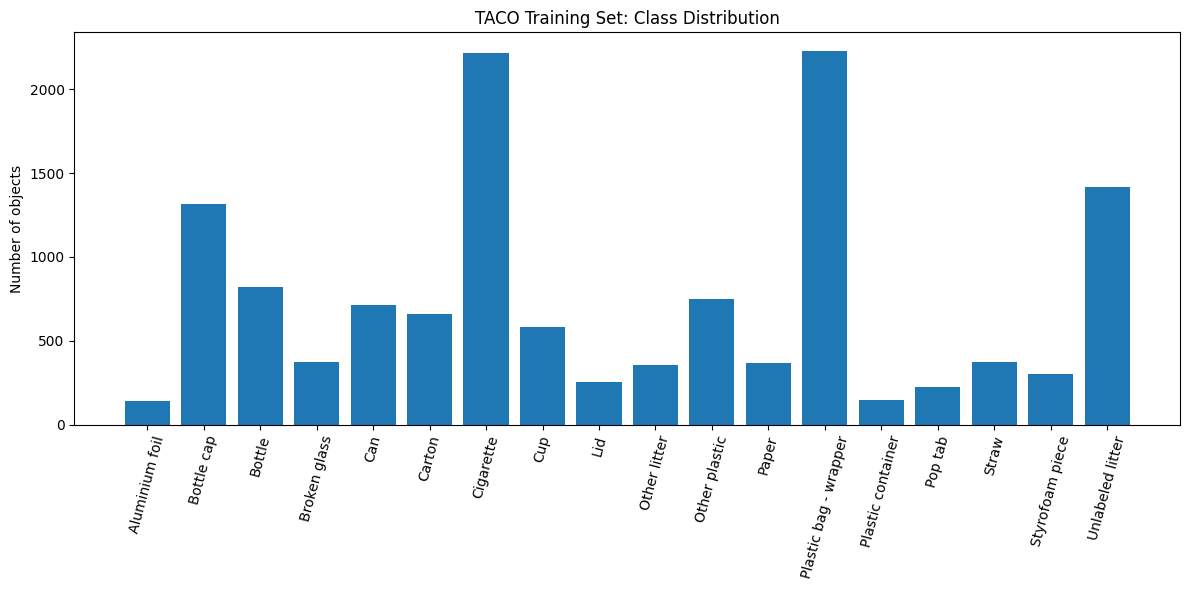

In [7]:
counts = [class_counts[i] for i in range(data["nc"])]

plt.figure(figsize=(12, 6))
plt.bar(data["names"], counts)

plt.xticks(rotation=75)
plt.ylabel("Number of objects")
plt.title("TACO Training Set: Class Distribution")
plt.tight_layout()
plt.show()

Loads of cigarettes, eh

In [8]:
!pip install -q ultralytics
from ultralytics import YOLO

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 19.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.0/91.0 kB 4.2 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.


In [9]:
model = YOLO("yolo11n.pt")

In [10]:
results = model.train(
    data=f"{BASE}/data.yaml",
    epochs=30,
    imgsz=640,
    batch=16,
    device=0
)

Ultralytics 8.4.163 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/input/datasets/vencerlanz09/taco-dataset-yolo-format/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train

/usr/local/lib/python3.12/dist-packages/ray/train/_internal/session.py:676: UserWarning: `get_trial_id` is meant to only be called inside a function that is executed by a Tuner or Trainer. Returning `None`.
  warnings.warn(


       2/30      2.78G       1.45      3.449      1.243         50        640: 100% ━━━━━━━━━━━━ 263/263 7.1it/s 37.2s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 54/54 5.4it/s 10.0s
                   all       1704       4830      0.199      0.184      0.073     0.0501

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       3/30      2.78G      1.442      3.173      1.219         30        640: 100% ━━━━━━━━━━━━ 263/263 7.1it/s 37.1s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 54/54 5.5it/s 9.9s
                   all       1704       4830      0.243      0.172      0.085     0.0553

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       4/30      2.78G      1.433       2.99      1.225         50        640: 100% ━━━━━━━━━━━━ 263/263 7.0it/s 37.4s
                 Class     Images  Instances      Bo

In [11]:
metrics = model.val(
    data=f"{BASE}/data.yaml",
    split="val",
    imgsz=640,
    batch=16,
    plots=True
)

Ultralytics 8.4.163 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
YOLO11n summary (fused): 100 layers, 2,585,662 parameters, 0 gradients, 6.4 GFLOPs
WARNING ⚠️ val: Slow image access detected (ping: 0.0±0.0 ms, read: 29.4±9.1 MB/s, size: 37.0 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips
val: Scanning /kaggle/input/datasets/vencerlanz09/taco-dataset-yolo-format/valid/labels... 1704 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1704/1704 521.3it/s 3.3s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/vencerlanz09/taco-dataset-yolo-format/valid is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 107/107 6.6it/s 16.2s
                   all       1704       4830      0.496       0.32      0.329      0.246
        Aluminium foil         48         62      0.592      0.403      0

In [12]:
print("mAP50:    ", metrics.box.map50)
print("mAP50-95: ", metrics.box.map)
print("Precision:", metrics.box.mp)
print("Recall:   ", metrics.box.mr)

mAP50:     0.3288011087316931
mAP50-95:  0.24561241988140664
Precision: 0.4960905227088882
Recall:    0.319890556314502


In [13]:
print(metrics.save_dir)

/kaggle/working/runs/detect/val


In [14]:
print(os.listdir(metrics.save_dir))

['val_batch1_labels.jpg', 'BoxP_curve.png', 'BoxPR_curve.png', 'confusion_matrix_normalized.png', 'val_batch1_pred.jpg', 'val_batch2_labels.jpg', 'BoxF1_curve.png', 'BoxR_curve.png', 'val_batch2_pred.jpg', 'confusion_matrix.png', 'val_batch0_pred.jpg', 'val_batch0_labels.jpg']


confusion_matrix.png


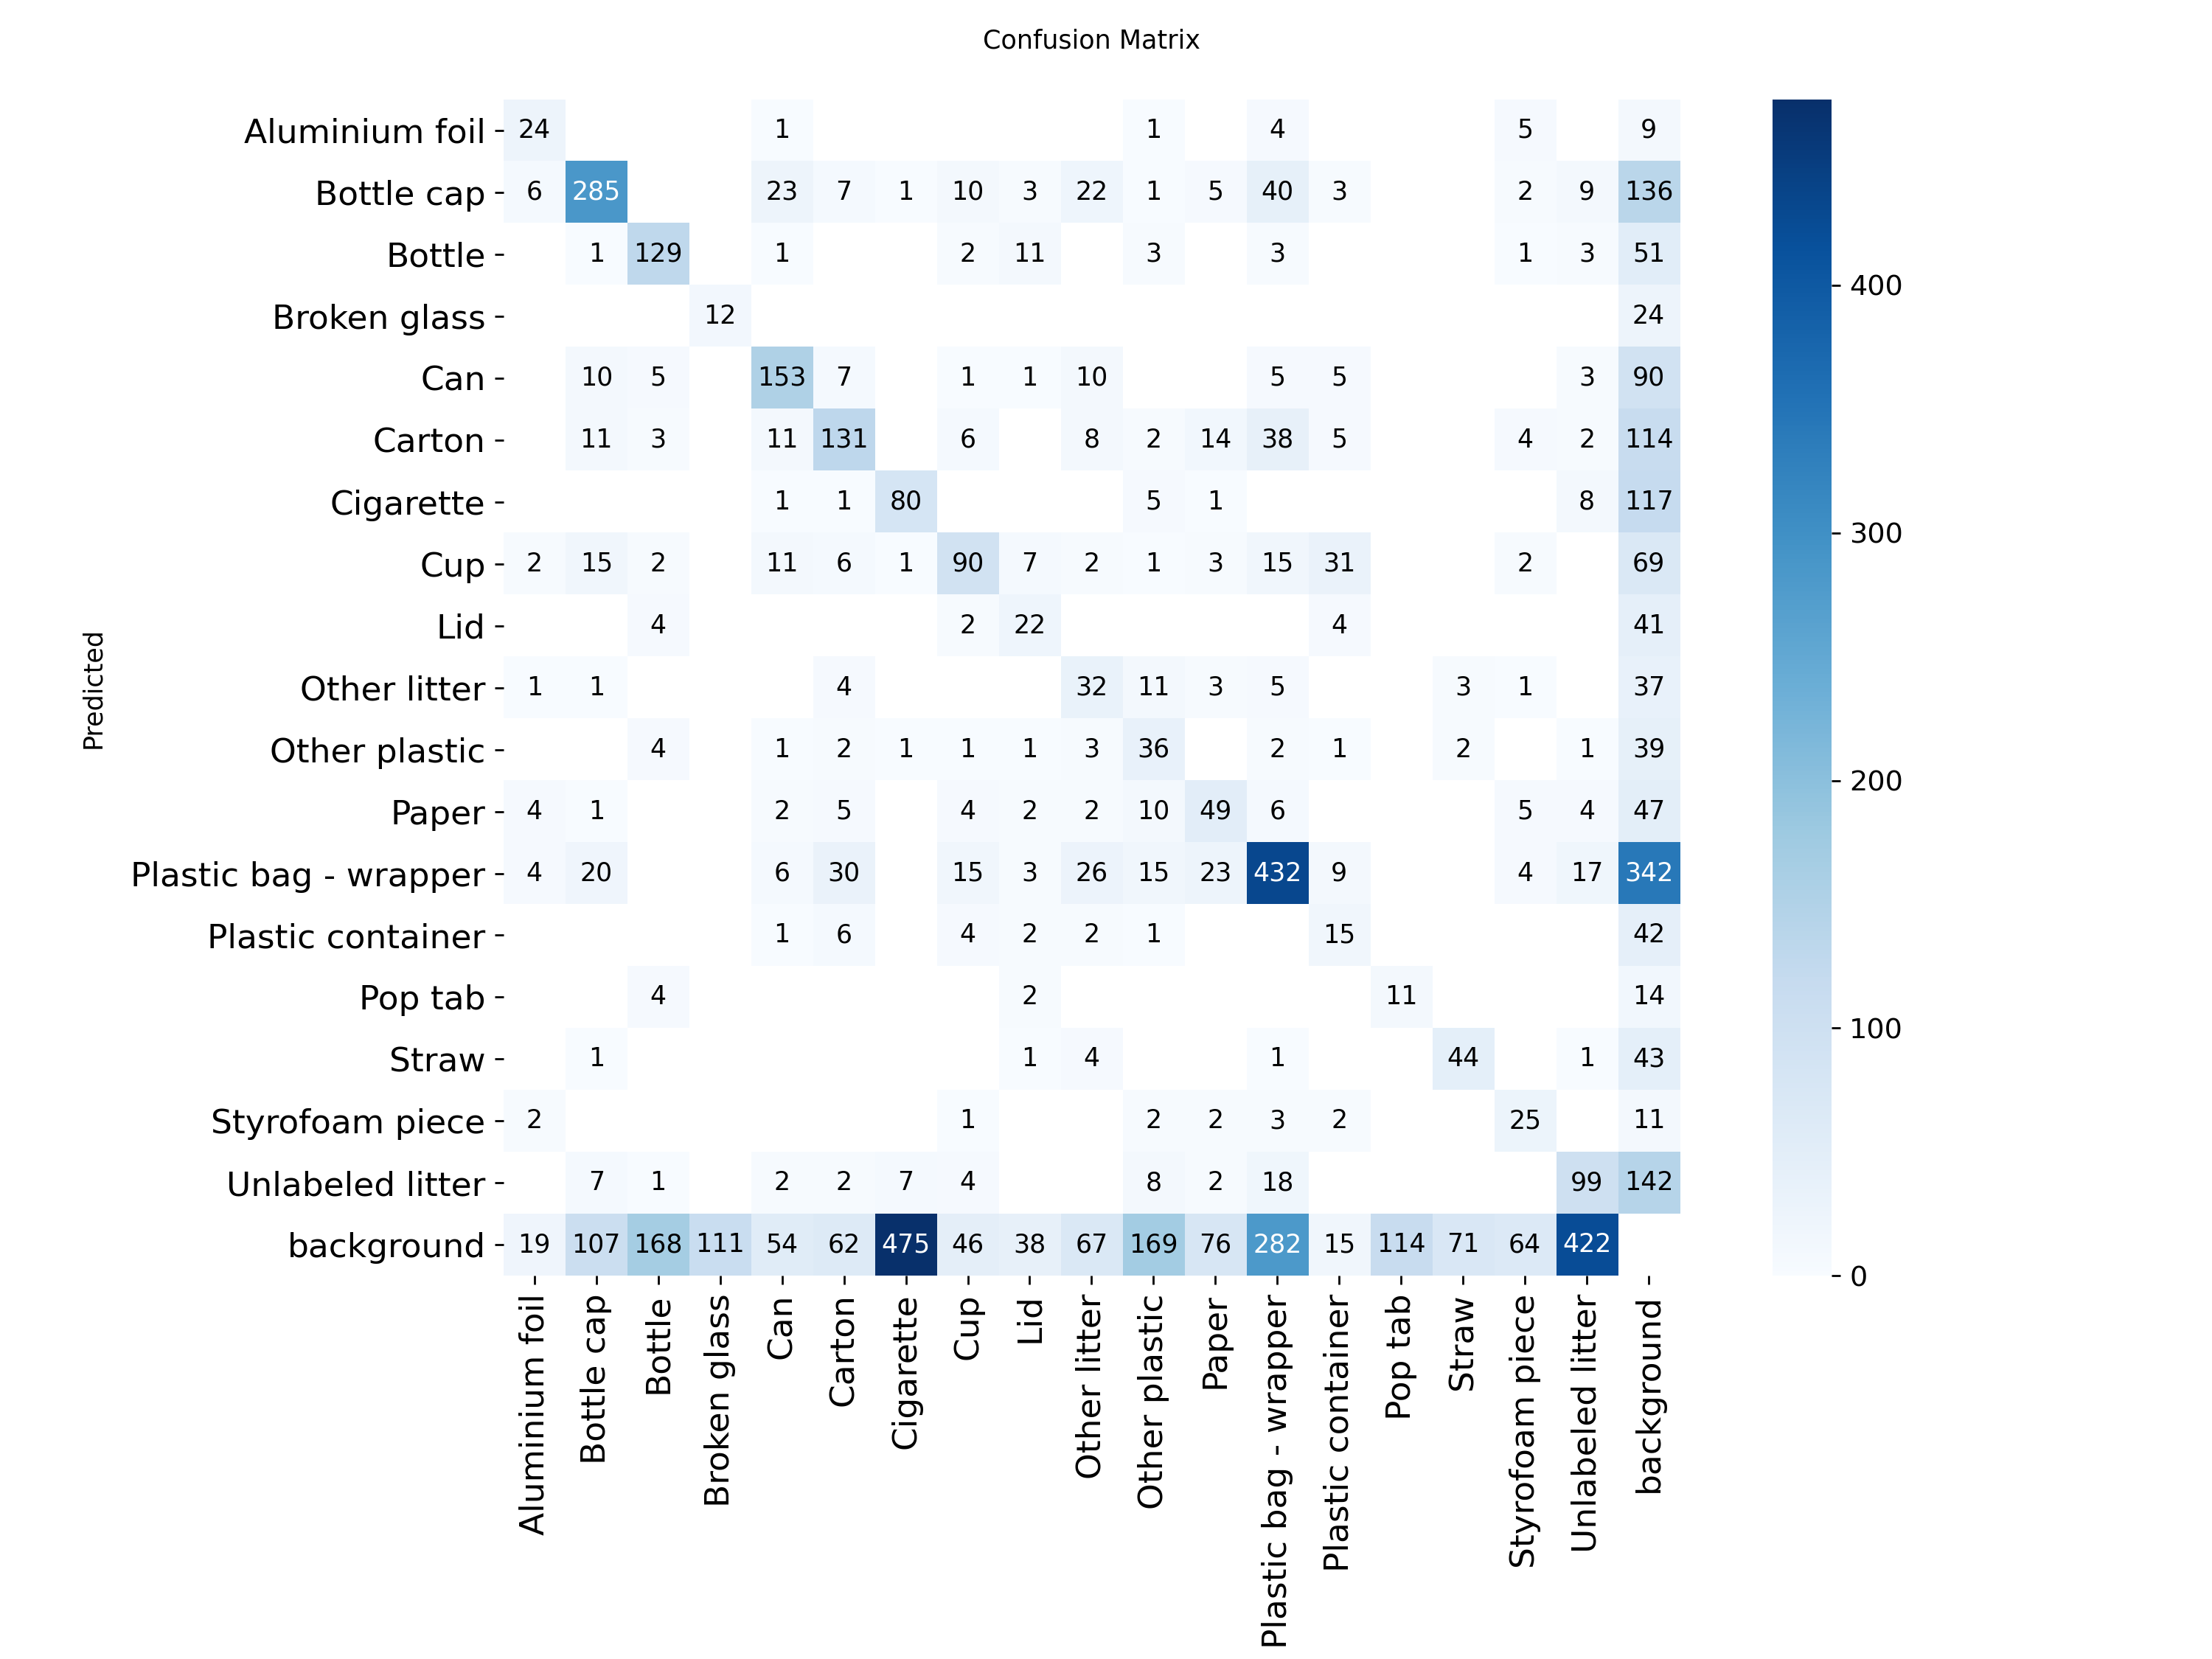

confusion_matrix_normalized.png


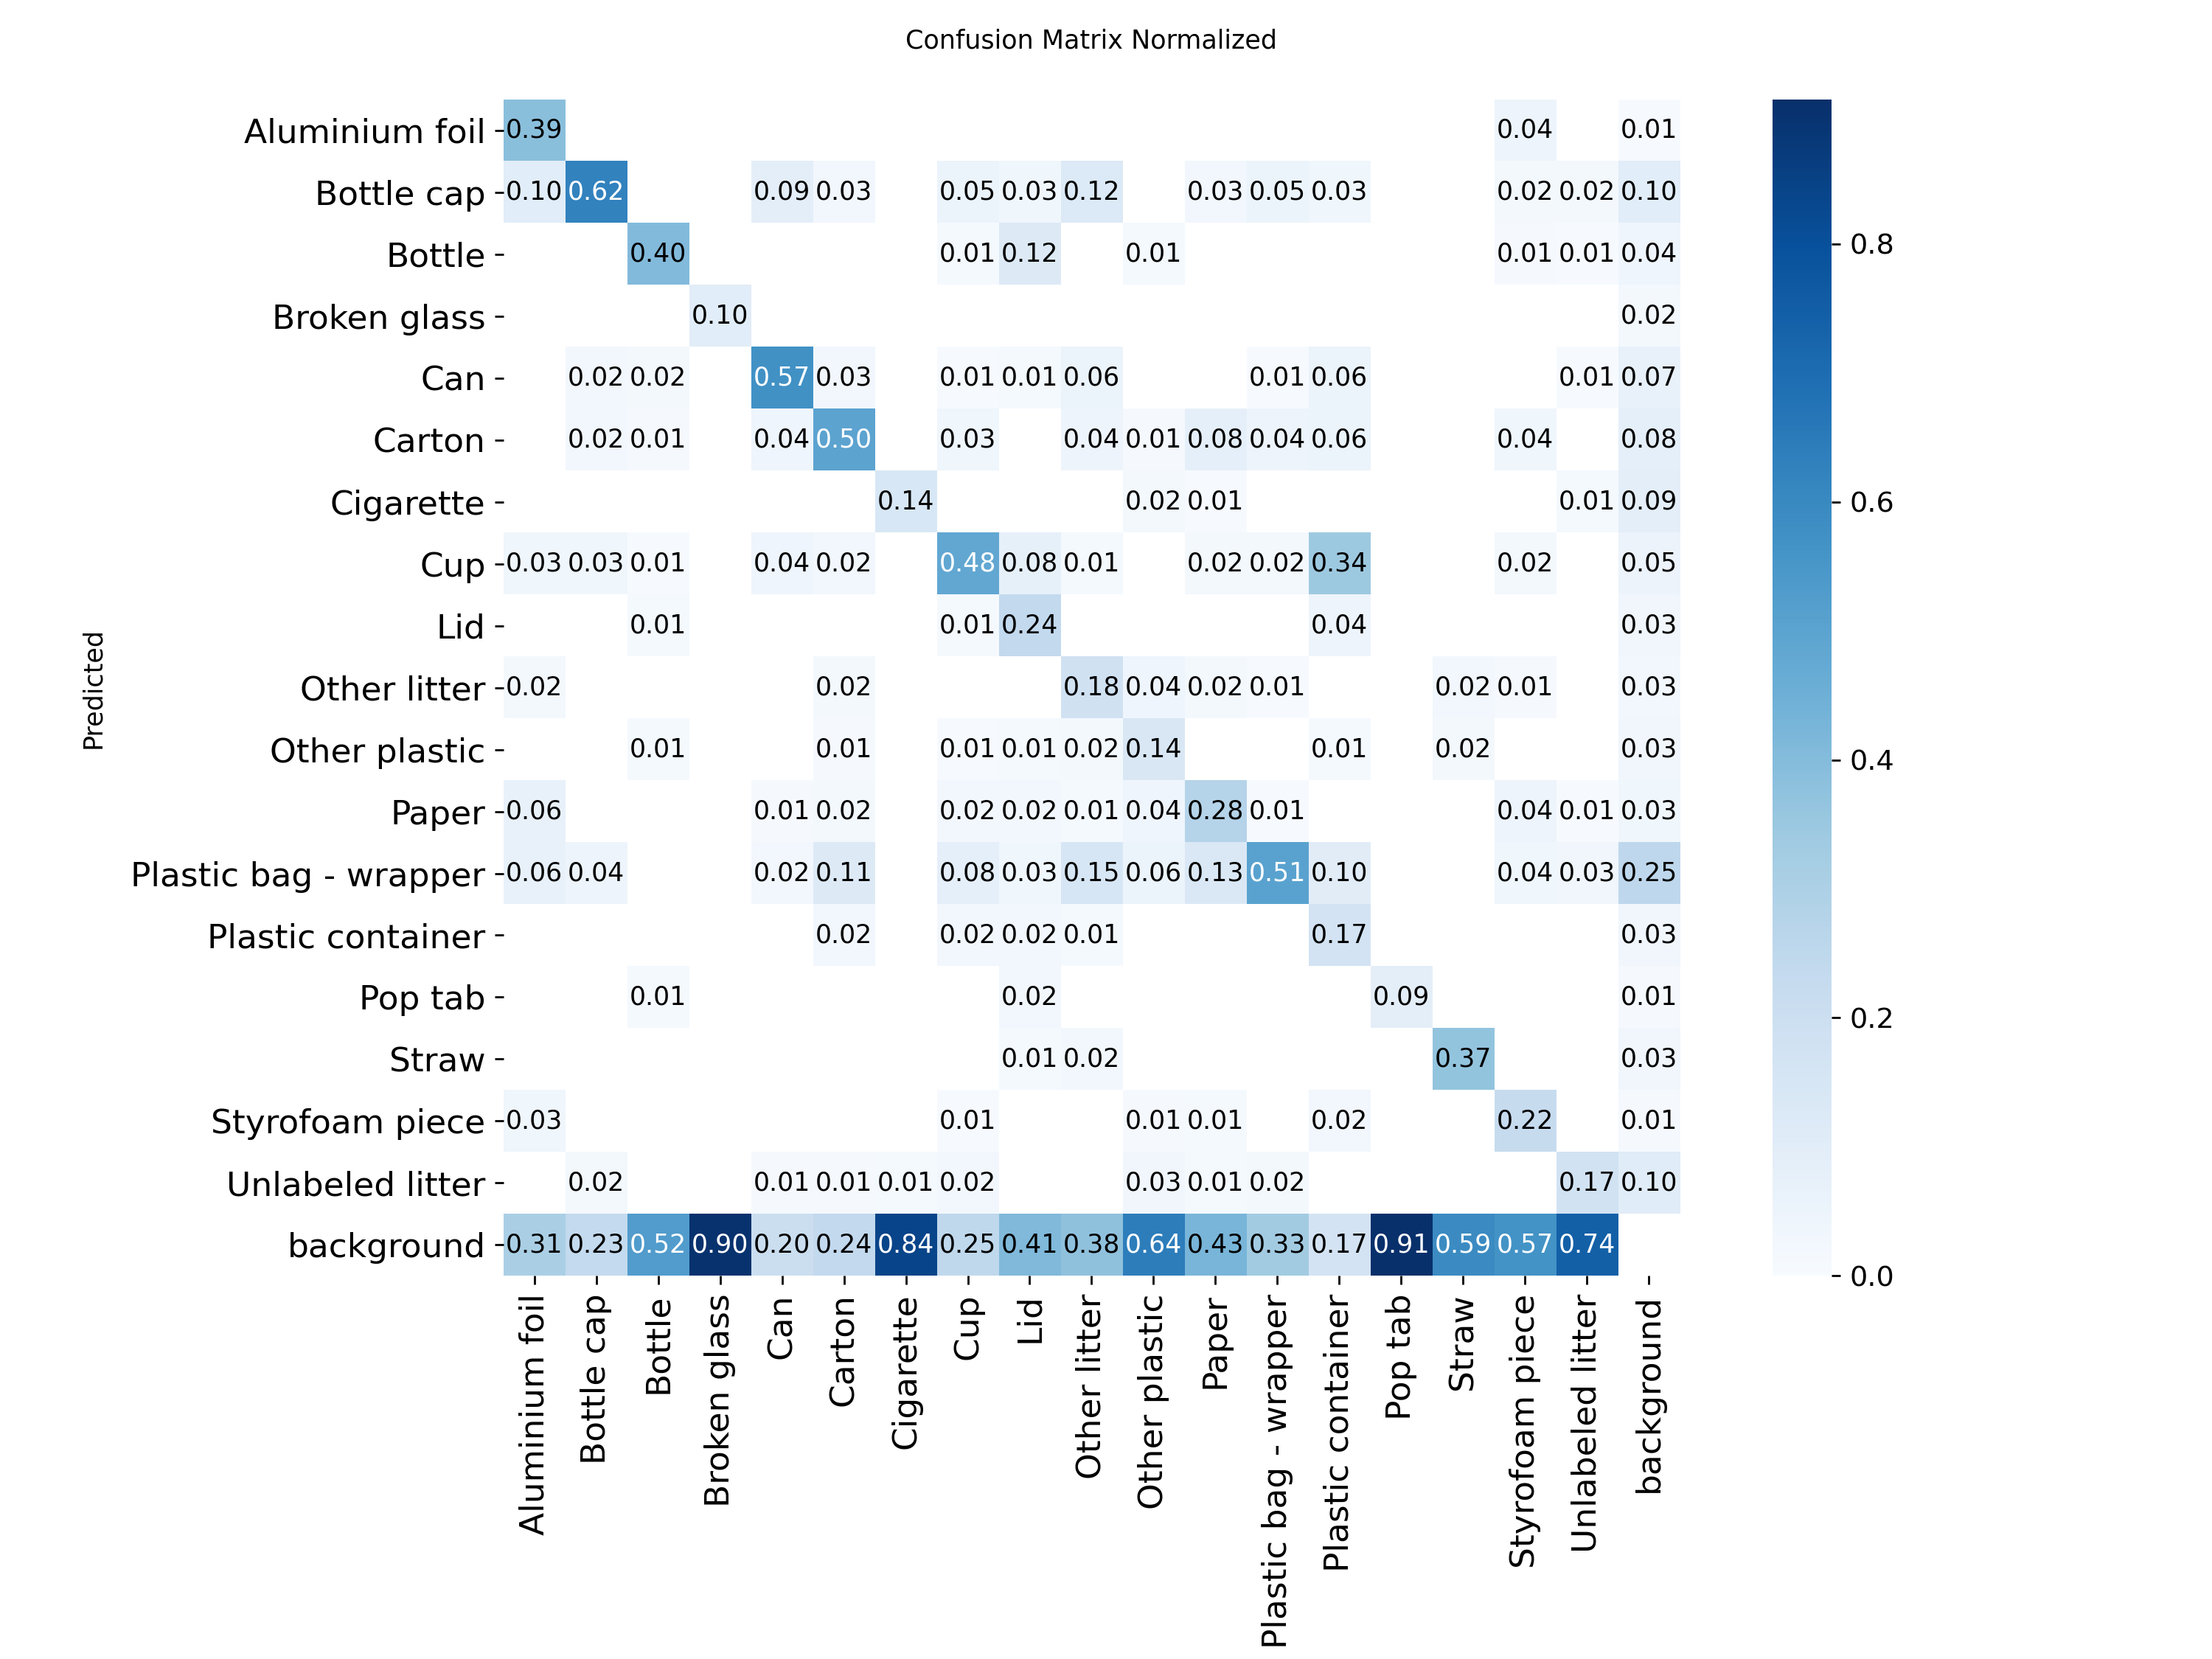

BoxPR_curve.png


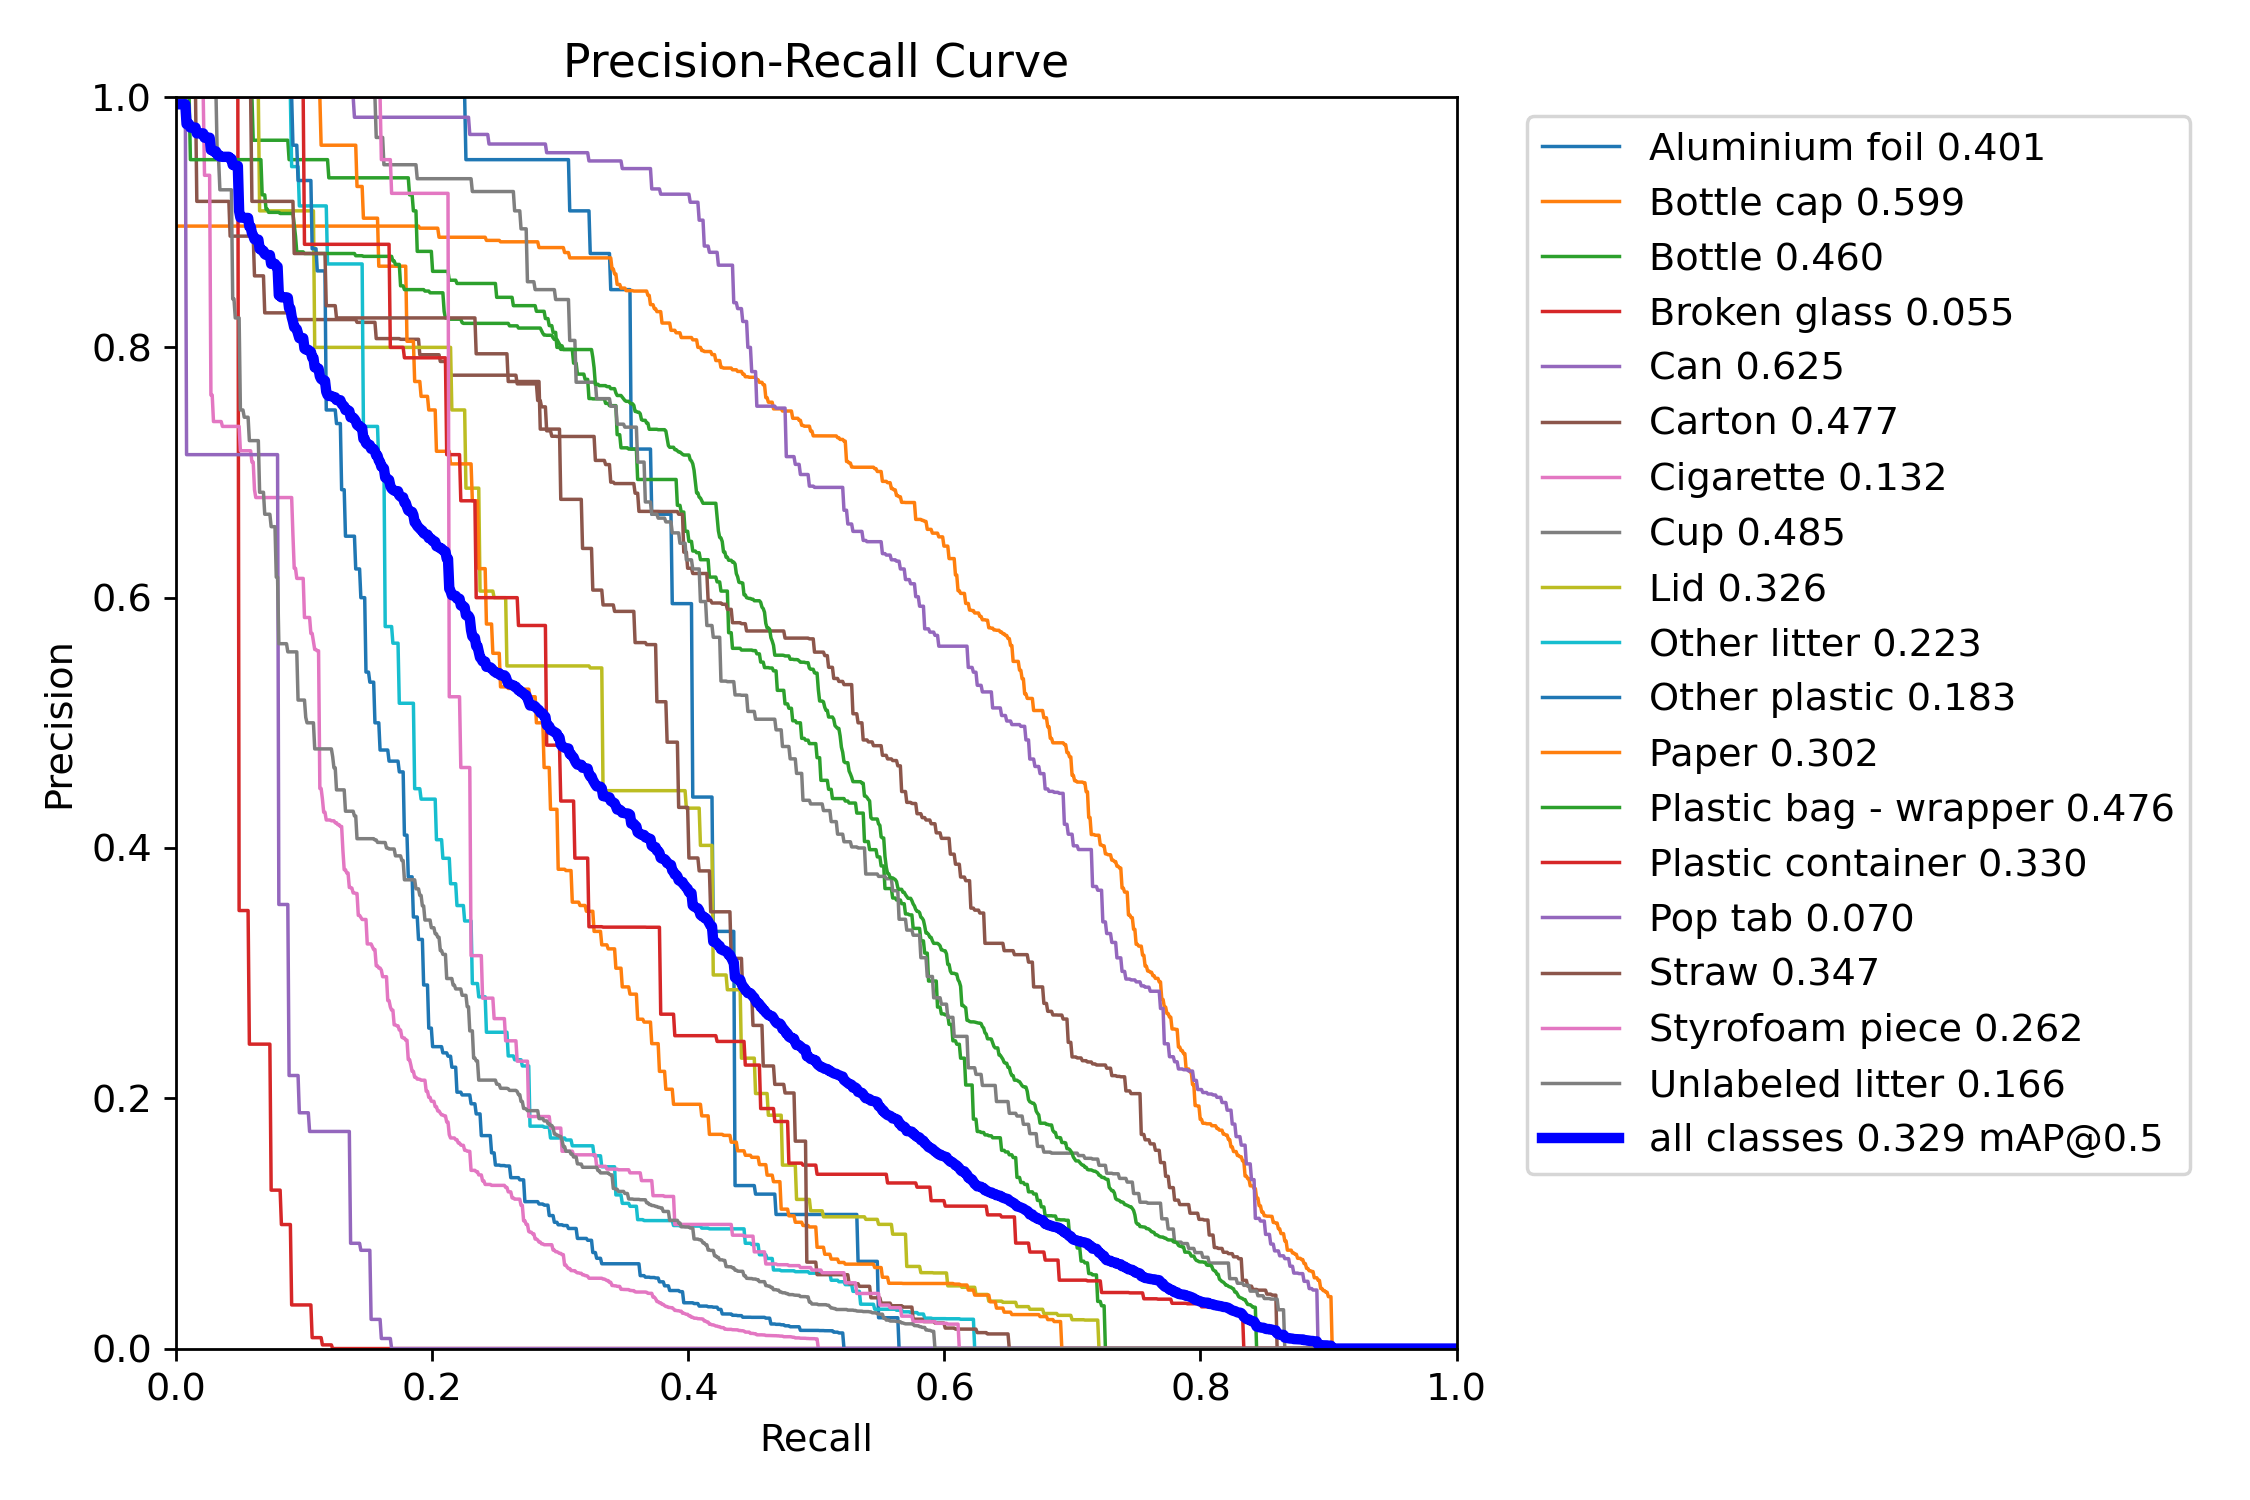

BoxP_curve.png


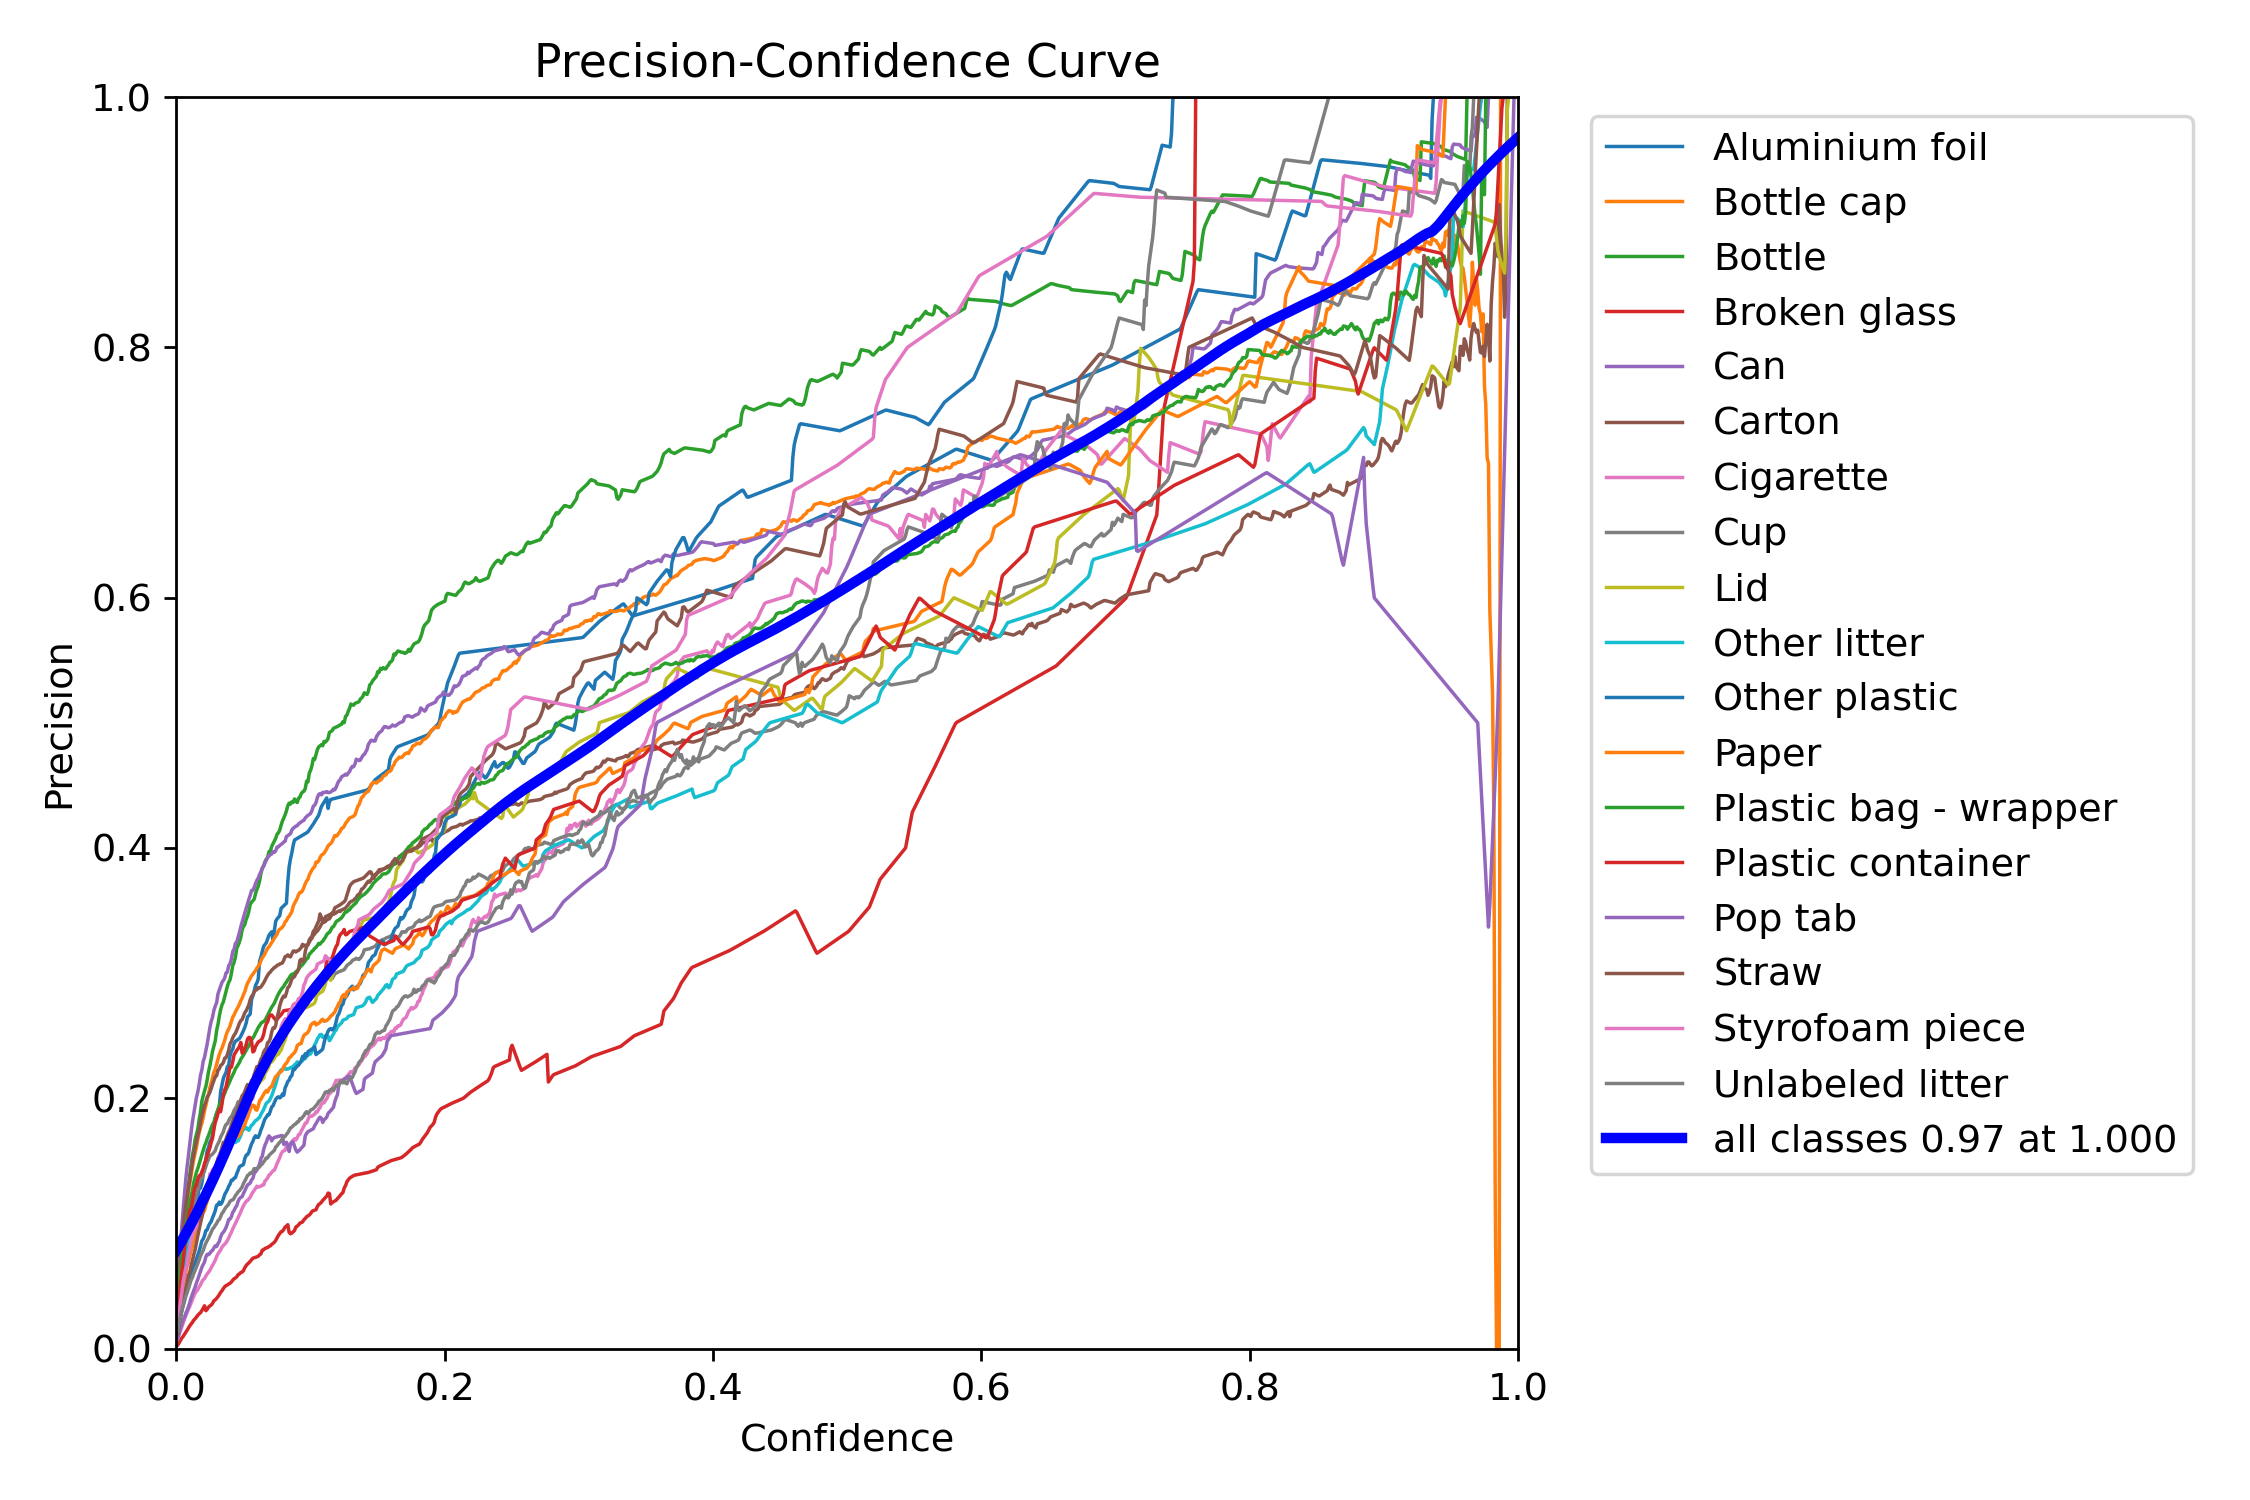

BoxR_curve.png


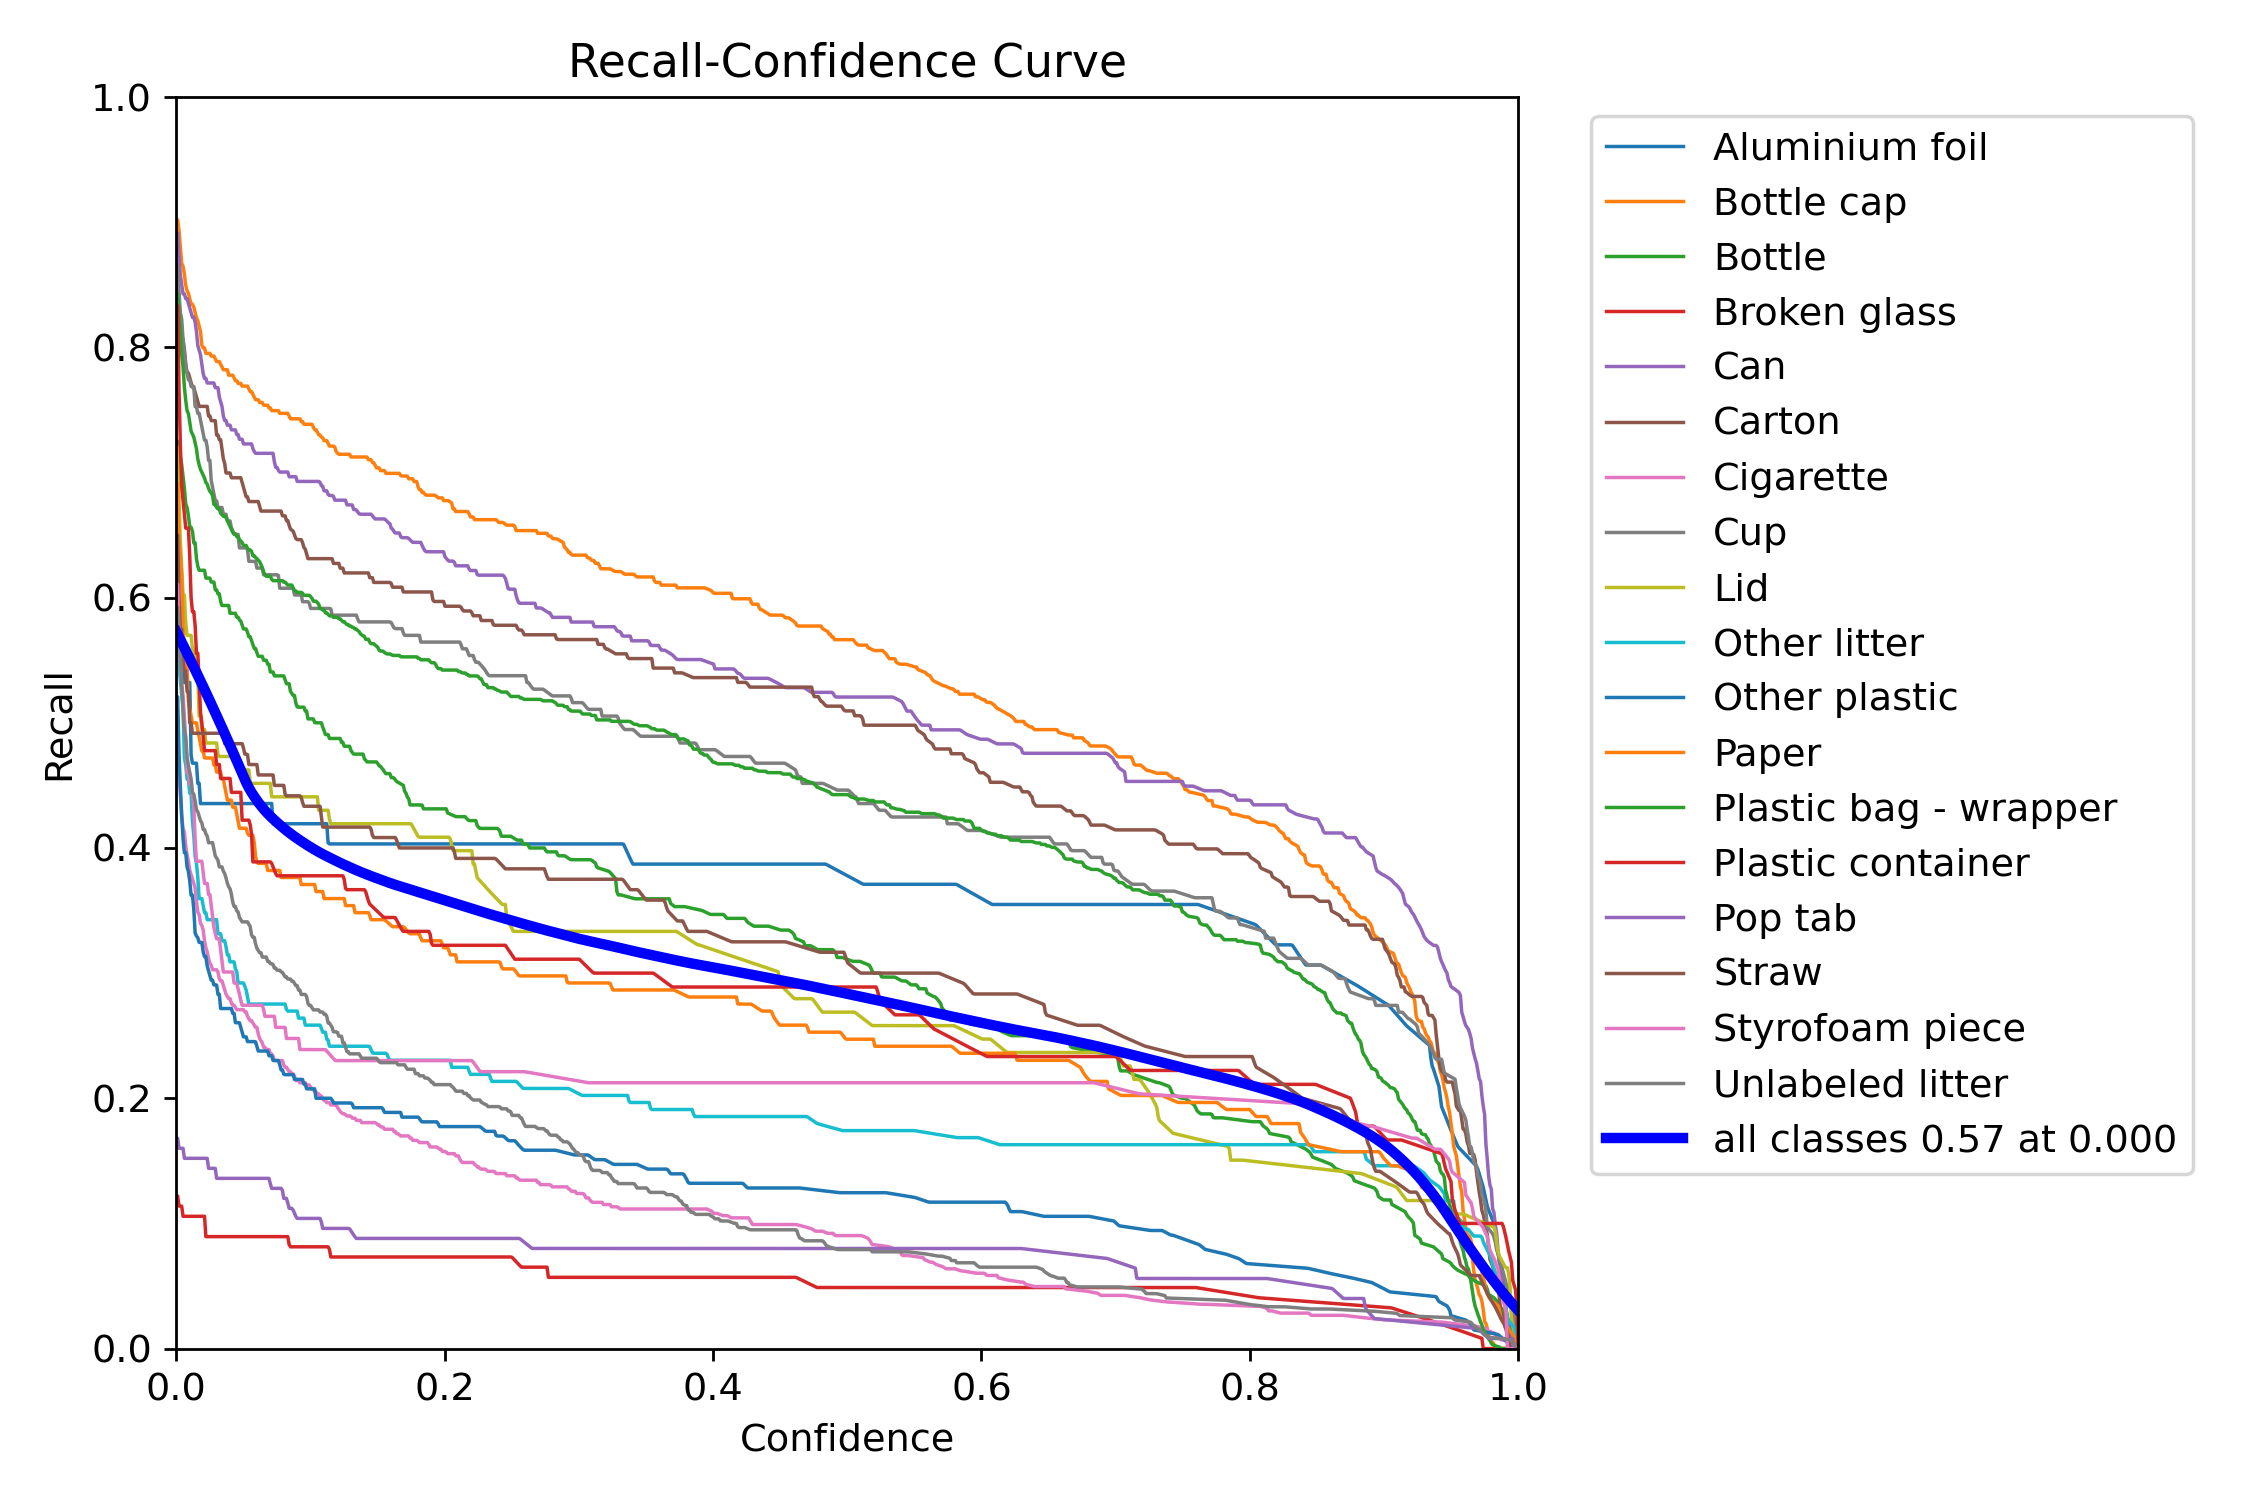

BoxF1_curve.png


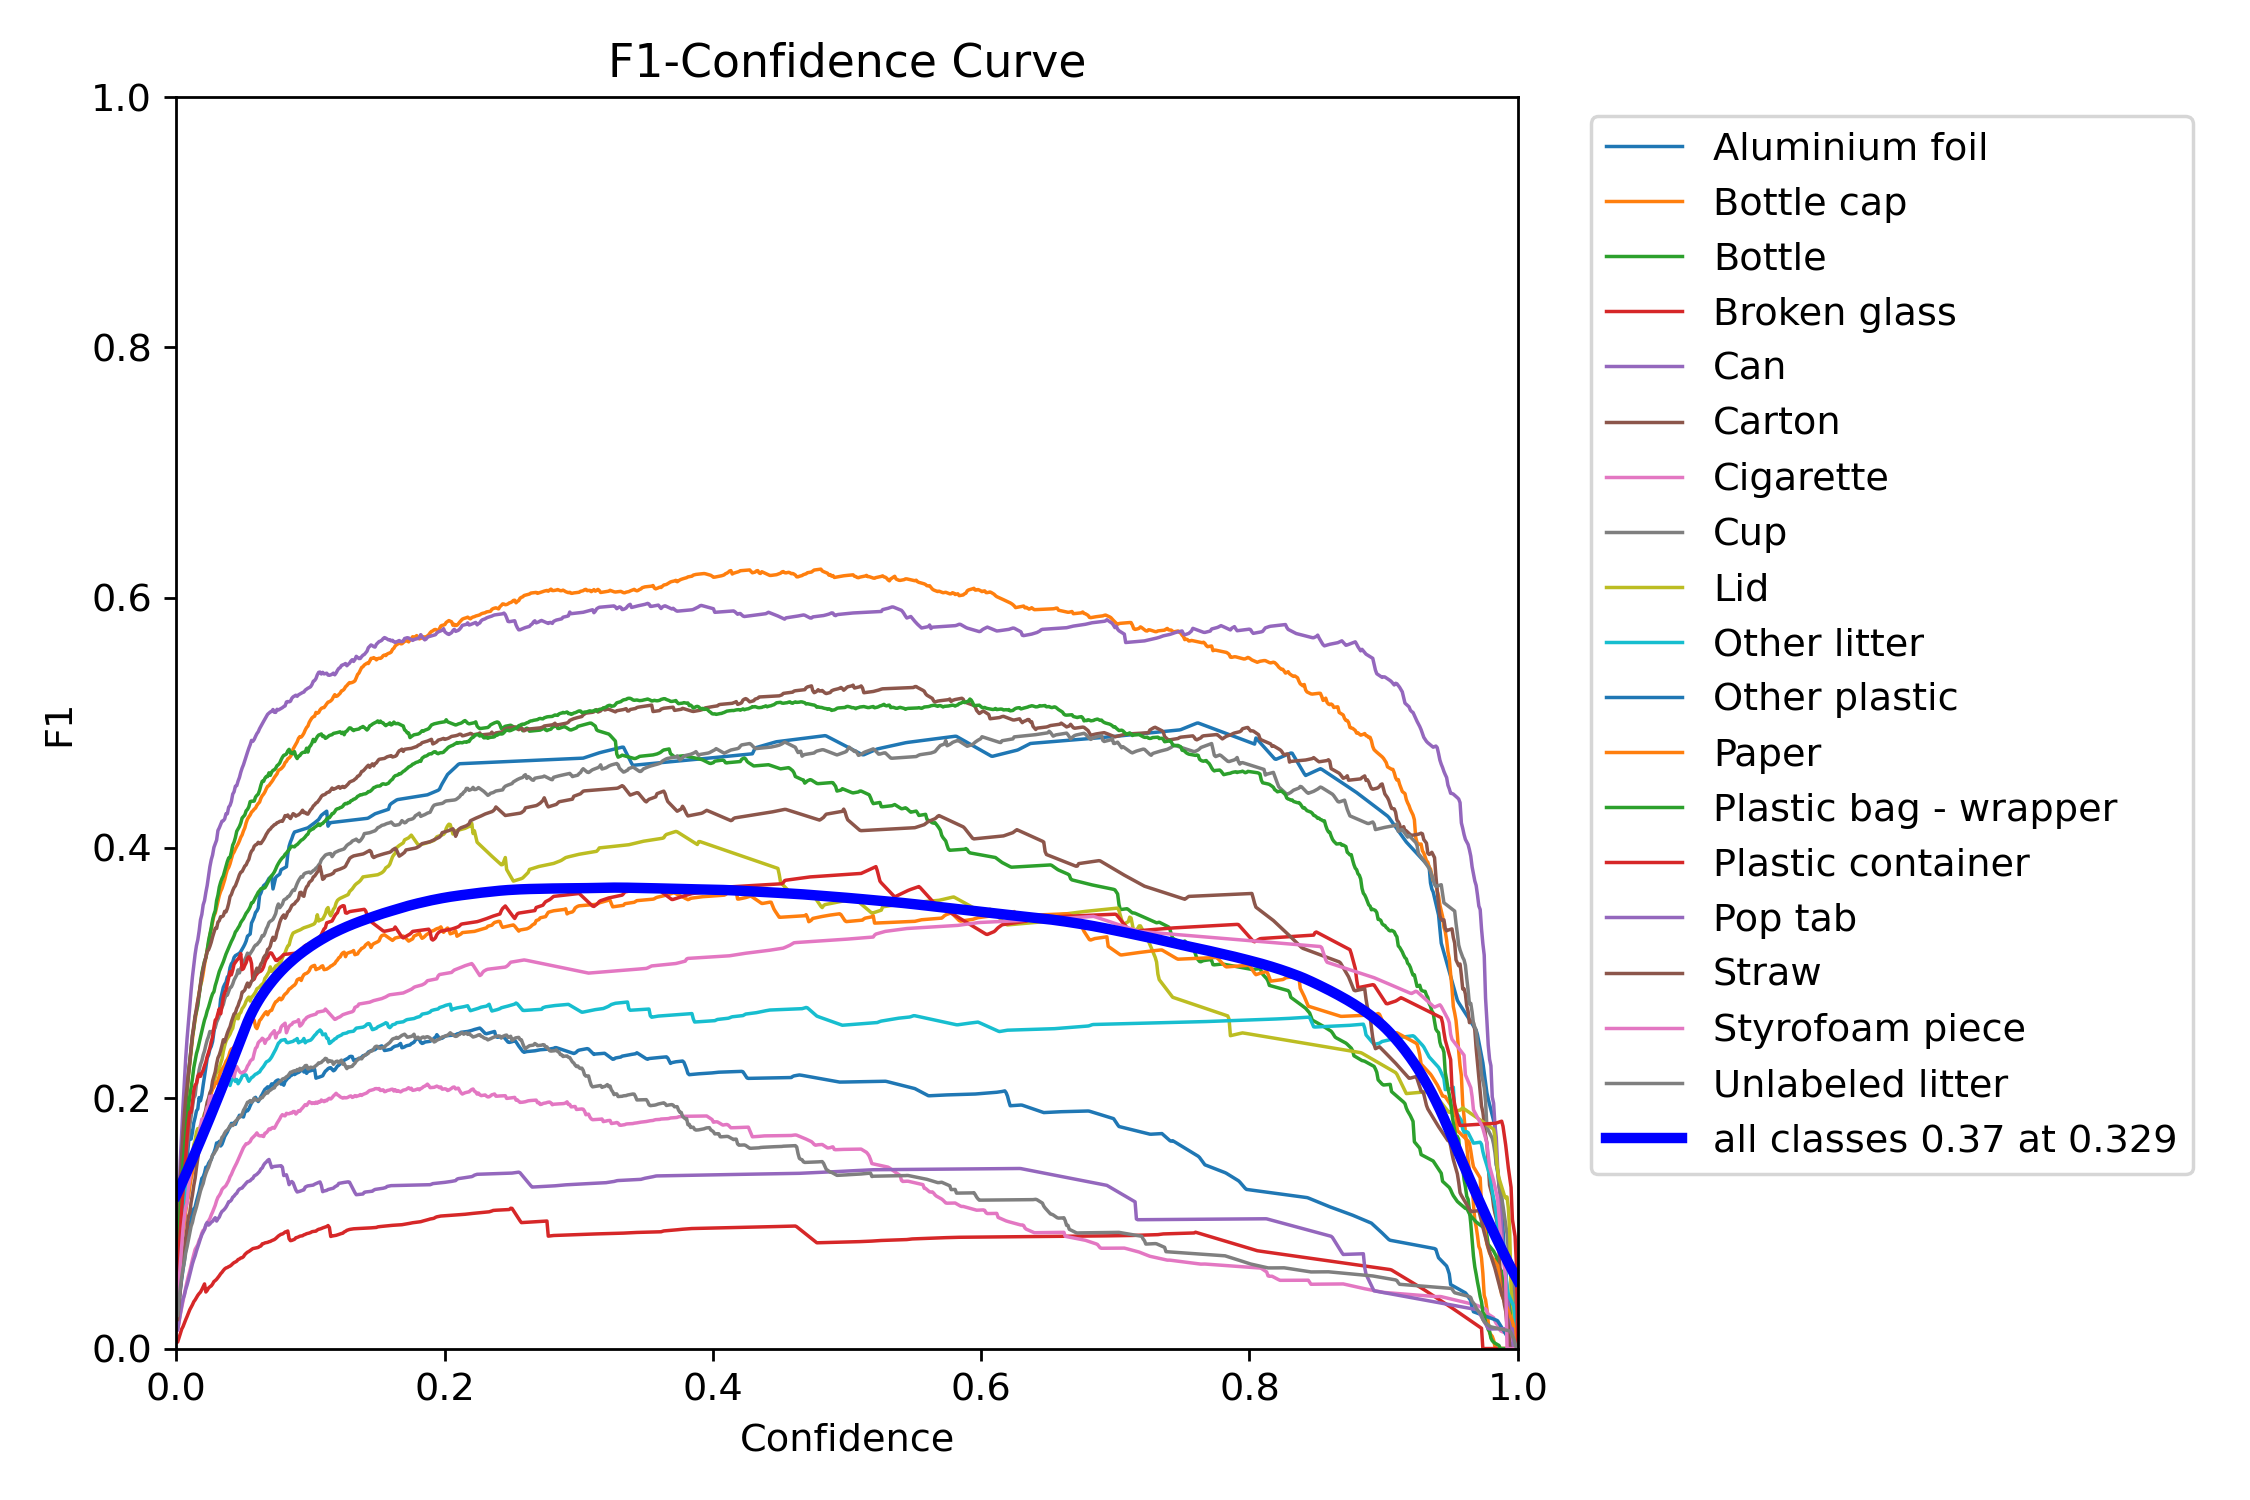

In [15]:
from PIL import Image
from IPython.display import display
import os

plot_files = [
    "confusion_matrix.png",
    "confusion_matrix_normalized.png",
    "BoxPR_curve.png",
    "BoxP_curve.png",
    "BoxR_curve.png",
    "BoxF1_curve.png"
]

for filename in plot_files:
    path = os.path.join(metrics.save_dir, filename)

    print(filename)
    display(Image.open(path))

In [16]:
for i, name in enumerate(data["names"]):
    print(
        f"{i:2} | {name:25} | "
        f"mAP50={metrics.box.ap50[i]:.3f} | "
        f"mAP50-95={metrics.box.ap[i]:.3f}"
    )

 0 | Aluminium foil            | mAP50=0.401 | mAP50-95=0.308
 1 | Bottle cap                | mAP50=0.599 | mAP50-95=0.448
 2 | Bottle                    | mAP50=0.460 | mAP50-95=0.296
 3 | Broken glass              | mAP50=0.055 | mAP50-95=0.031
 4 | Can                       | mAP50=0.625 | mAP50-95=0.488
 5 | Carton                    | mAP50=0.477 | mAP50-95=0.399
 6 | Cigarette                 | mAP50=0.132 | mAP50-95=0.063
 7 | Cup                       | mAP50=0.485 | mAP50-95=0.396
 8 | Lid                       | mAP50=0.326 | mAP50-95=0.252
 9 | Other litter              | mAP50=0.223 | mAP50-95=0.177
10 | Other plastic             | mAP50=0.183 | mAP50-95=0.123
11 | Paper                     | mAP50=0.302 | mAP50-95=0.230
12 | Plastic bag - wrapper     | mAP50=0.476 | mAP50-95=0.339
13 | Plastic container         | mAP50=0.330 | mAP50-95=0.275
14 | Pop tab                   | mAP50=0.070 | mAP50-95=0.049
15 | Straw                     | mAP50=0.347 | mAP50-95=0.228
16 | Sty

In [17]:
print(f"mAP50:    {metrics.box.map50:.4f}")
print(f"mAP50-95: {metrics.box.map:.4f}")
print(f"Precision: {metrics.box.mp:.4f}")
print(f"Recall:    {metrics.box.mr:.4f}")

mAP50:    0.3288
mAP50-95: 0.2456
Precision: 0.4961
Recall:    0.3199


In [18]:
#Let's grab, say, 12 validation images:
import random

val_images = [
    os.path.join(VALID_IMG, f)
    for f in os.listdir(VALID_IMG)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

sample_images = random.sample(val_images, 12)

pred_results = model.predict(
    source=sample_images,
    imgsz=640,
    conf=0.25,
    max_det=50
)


0: 640x640 1 Cup, 1 Plastic bag - wrapper, 4.6ms
1: 640x640 1 Bottle cap, 1 Cigarette, 1 Cup, 4.6ms
2: 640x640 2 Bottle caps, 4.6ms
3: 640x640 1 Can, 1 Plastic bag - wrapper, 4.6ms
4: 640x640 (no detections), 4.6ms
5: 640x640 2 Cups, 1 Paper, 1 Plastic bag - wrapper, 4.6ms
6: 640x640 1 Plastic bag - wrapper, 1 Unlabeled litter, 4.6ms
7: 640x640 1 Plastic bag - wrapper, 4.6ms
8: 640x640 1 Plastic bag - wrapper, 4.6ms
9: 640x640 (no detections), 4.6ms
10: 640x640 1 Carton, 1 Plastic bag - wrapper, 4.6ms
11: 640x640 1 Bottle cap, 4.6ms
Speed: 1.8ms preprocess, 4.6ms inference, 0.8ms postprocess per image at shape (1, 3, 640, 640)


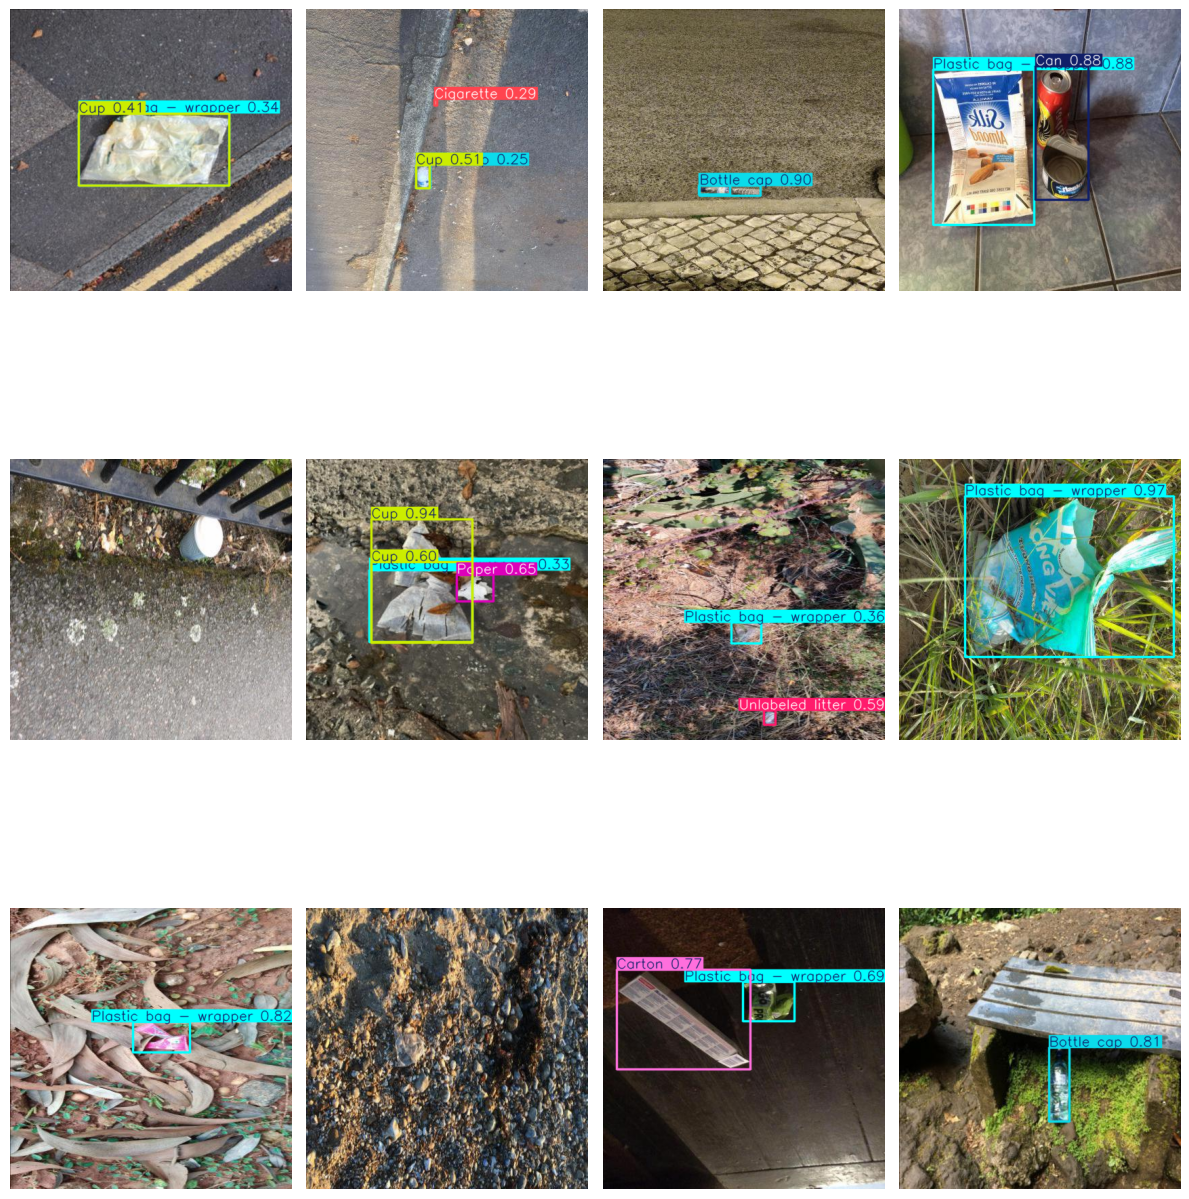

In [19]:
from PIL import Image
from IPython.display import display

fig, axes= plt.subplots(3,4, figsize = (12, 15))
axes = axes.ravel()

for i,r in enumerate(pred_results):
    axes[i].imshow(r.plot()[:, :, ::-1])
    axes[i].axis("off")

plt.tight_layout()
plt.show()

Umm..definitely gotta improve on this